# Прогнозирование интракраниальной прогрессии на медицинских табличных данных

## Задача
Построить модель бинарной классификации для предсказания интракраниальной прогрессии по клиническим признакам пациента.

## Этапы работы
1. Очистка и предобработка данных.
2. Конструирование признаков на основе дат и клинических переменных.
3. Сравнение нескольких моделей классификации.
4. Подбор гиперпараметров для лучшей модели.
5. Предсказание на тестовой выборке.

# Импорт, настройки

In [55]:
!pip install catboost

In [56]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import scipy.stats as sps
from datetime import datetime
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, make_scorer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.model_selection import ShuffleSplit
plt.style.use('ggplot')
df = pd.read_csv('train.csv')

# 1. Обработка данных

## Фильтрация

### Интракраниальная прогрессия

In [57]:
df = df.dropna(subset=["Интракраниальная прогрессия"]).copy()

def determine_expected_ip(local, distant):
    has_local = isinstance(local, str) and local != "нет"
    has_distant = isinstance(distant, str) and distant != "нет"
    if has_local or has_distant:
        return 1
    else:
        return 0


def refactor_existing_ip(ip):
  if ip in ['ЛР', 'ДМ', 'ЛР+ДМ']:
    return 1
  elif ip == 'нет':
    return 0
  else:
    return ip


df["Ожидаемая прогрессия"] = df.apply(
    lambda row: determine_expected_ip(row["Локальный рецидив"], row["Дистантные метастазы"]),
    axis=1
)
df['Интракраниальная прогрессия'] = df['Интракраниальная прогрессия'].apply(refactor_existing_ip)

#Вывод несоотвествий
df[df["Интракраниальная прогрессия"] != df["Ожидаемая прогрессия"]][["Локальный рецидив", "Дистантные метастазы", "Интракраниальная прогрессия", "Ожидаемая прогрессия"]]

,Локальный рецидив,Дистантные метастазы,Интракраниальная прогрессия,Ожидаемая прогрессия
46,22.12.2015,нет,0,1
67,нет,05.10.2017,0,1
99,10.06.2015,нет,0,1
135,нет,нет,1,0
182,нет,нет,1,0
216,нет,11.10.2017,0,1
219,нет,20.12.2016,0,1
319,нет,05.06.2017,0,1
328,нет,09.05.2009,0,1
426,22.10.2012,нет,0,1


In [58]:
df = df.drop(["Локальный рецидив", "Дистантные метастазы", "Интракраниальная прогрессия"], axis=1)
df = df.rename(columns={'Ожидаемая прогрессия': 'Интракраниальная прогрессия'})

### Булевые признаки

In [59]:
def to_bool(series):
  result = series.copy()
  result = result.replace({
      'есть': True,
      'нет': False
  })
  return result

df["Экстракраниальные метастазы"] = to_bool(df["Экстракраниальные метастазы"])
df["Активирующие мутации"] = to_bool(df["Активирующие мутации"])

print(df["Экстракраниальные метастазы"].unique())
print(df["Активирующие мутации"].unique())

[True nan False]
[True False nan]


### Признаки с плавающей точкой

In [60]:
def str_to_float(series):
  result = series.copy()
  result = result.str.replace(',', '.')
  result = result.apply(float)
  return result


df['Суммарный объем очагов'] = str_to_float(df['Суммарный объем очагов'])
df['Объем максимального очага'] = str_to_float(df['Объем максимального очага'])

### Пол

In [61]:
def normalize_sex(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x == 'м':
        return 'М'
    if x == 'ж':
        return 'Ж'
    return np.nan

df['Пол'] = df['Пол'].apply(normalize_sex)

### Замена "нет" на NaN

In [62]:
df['Дата развития МГМ'] = df['Дата развития МГМ'].replace("нет", np.nan)
df['Дата постановки онкологического диагноза / начала первичного лечения'] = df['Дата постановки онкологического диагноза / начала первичного лечения'].replace("нет", np.nan)

### Избавление от NaN

In [63]:
df = df.dropna(subset=["Дата развития МГМ", "Дата постановки онкологического диагноза / начала первичного лечения"]).copy()

## Добавление признаков

### Возраст

In [64]:
def calculate_age(birth, first_rx):
    birth = pd.to_datetime(birth, errors='coerce')
    first_rx = pd.to_datetime(first_rx, errors='coerce')
    if pd.isna(birth) or pd.isna(first_rx):
        return np.nan
    age = first_rx.year - birth.year
    if (first_rx.month, first_rx.day) < (birth.month, birth.day):
        age -= 1
    return age


df["Возраст"] = df.apply(lambda row: calculate_age(row["Дата рождения"], row["Дата 1-ой РХ"]), axis=1)
df = df.drop('Дата рождения', axis=1)

/tmp/ipykernel_7499/3858549362.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  birth = pd.to_datetime(birth, errors='coerce')


### Время реагирования

In [65]:
def time_to_react(mgm, first):
    mgm = pd.to_datetime(mgm, errors='coerce')
    first = pd.to_datetime(first, errors='coerce')
    if pd.isna(mgm) or pd.isna(first):
        return np.nan
    return (first - mgm).days


df["Время реагирования"] = df.apply(lambda row: time_to_react(row["Дата развития МГМ"], row["Дата 1-ой РХ"]), axis=1)
df["Время реагирования"] = pd.to_numeric(df["Время реагирования"], errors='coerce')
df = df[df["Время реагирования"] >= 0]
df = df.drop('Дата 1-ой РХ', axis=1)

### Время метастазирования

In [66]:
def time_to_mgm(mgm1, first_seen):
    mgm1 = pd.to_datetime(mgm1, errors='coerce')
    first_seen = pd.to_datetime(first_seen, errors='coerce')
    if pd.isna(mgm1) or pd.isna(first_seen):
        return np.nan
    return (mgm1 - first_seen).days


df["Время метастазирования"] = df.apply(lambda row: time_to_mgm(row["Дата развития МГМ"], row["Дата постановки онкологического диагноза / начала первичного лечения"]), axis=1)
df["Время метастазирования"] = pd.to_numeric(df["Время метастазирования"], errors='coerce')
df = df.drop(['Дата развития МГМ', 'Дата постановки онкологического диагноза / начала первичного лечения'], axis=1)

/tmp/ipykernel_7499/1289759378.py:3: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  first_seen = pd.to_datetime(first_seen, errors='coerce')


### Операции

In [67]:
def map_binary(x):
    if pd.isna(x):
        return np.nan
    elif str(x).strip().lower() == 'нет':
        return 0
    else:
        return 1


df['ОВГМ'] = df['Дата проведения ОВГМ'].apply(map_binary)
df['Операция'] = df['Дата операции на ГМ'].apply(map_binary)

## Поиск лишних признаков

Text(0.5, 1.0, 'Корреляционная матрица признаков')

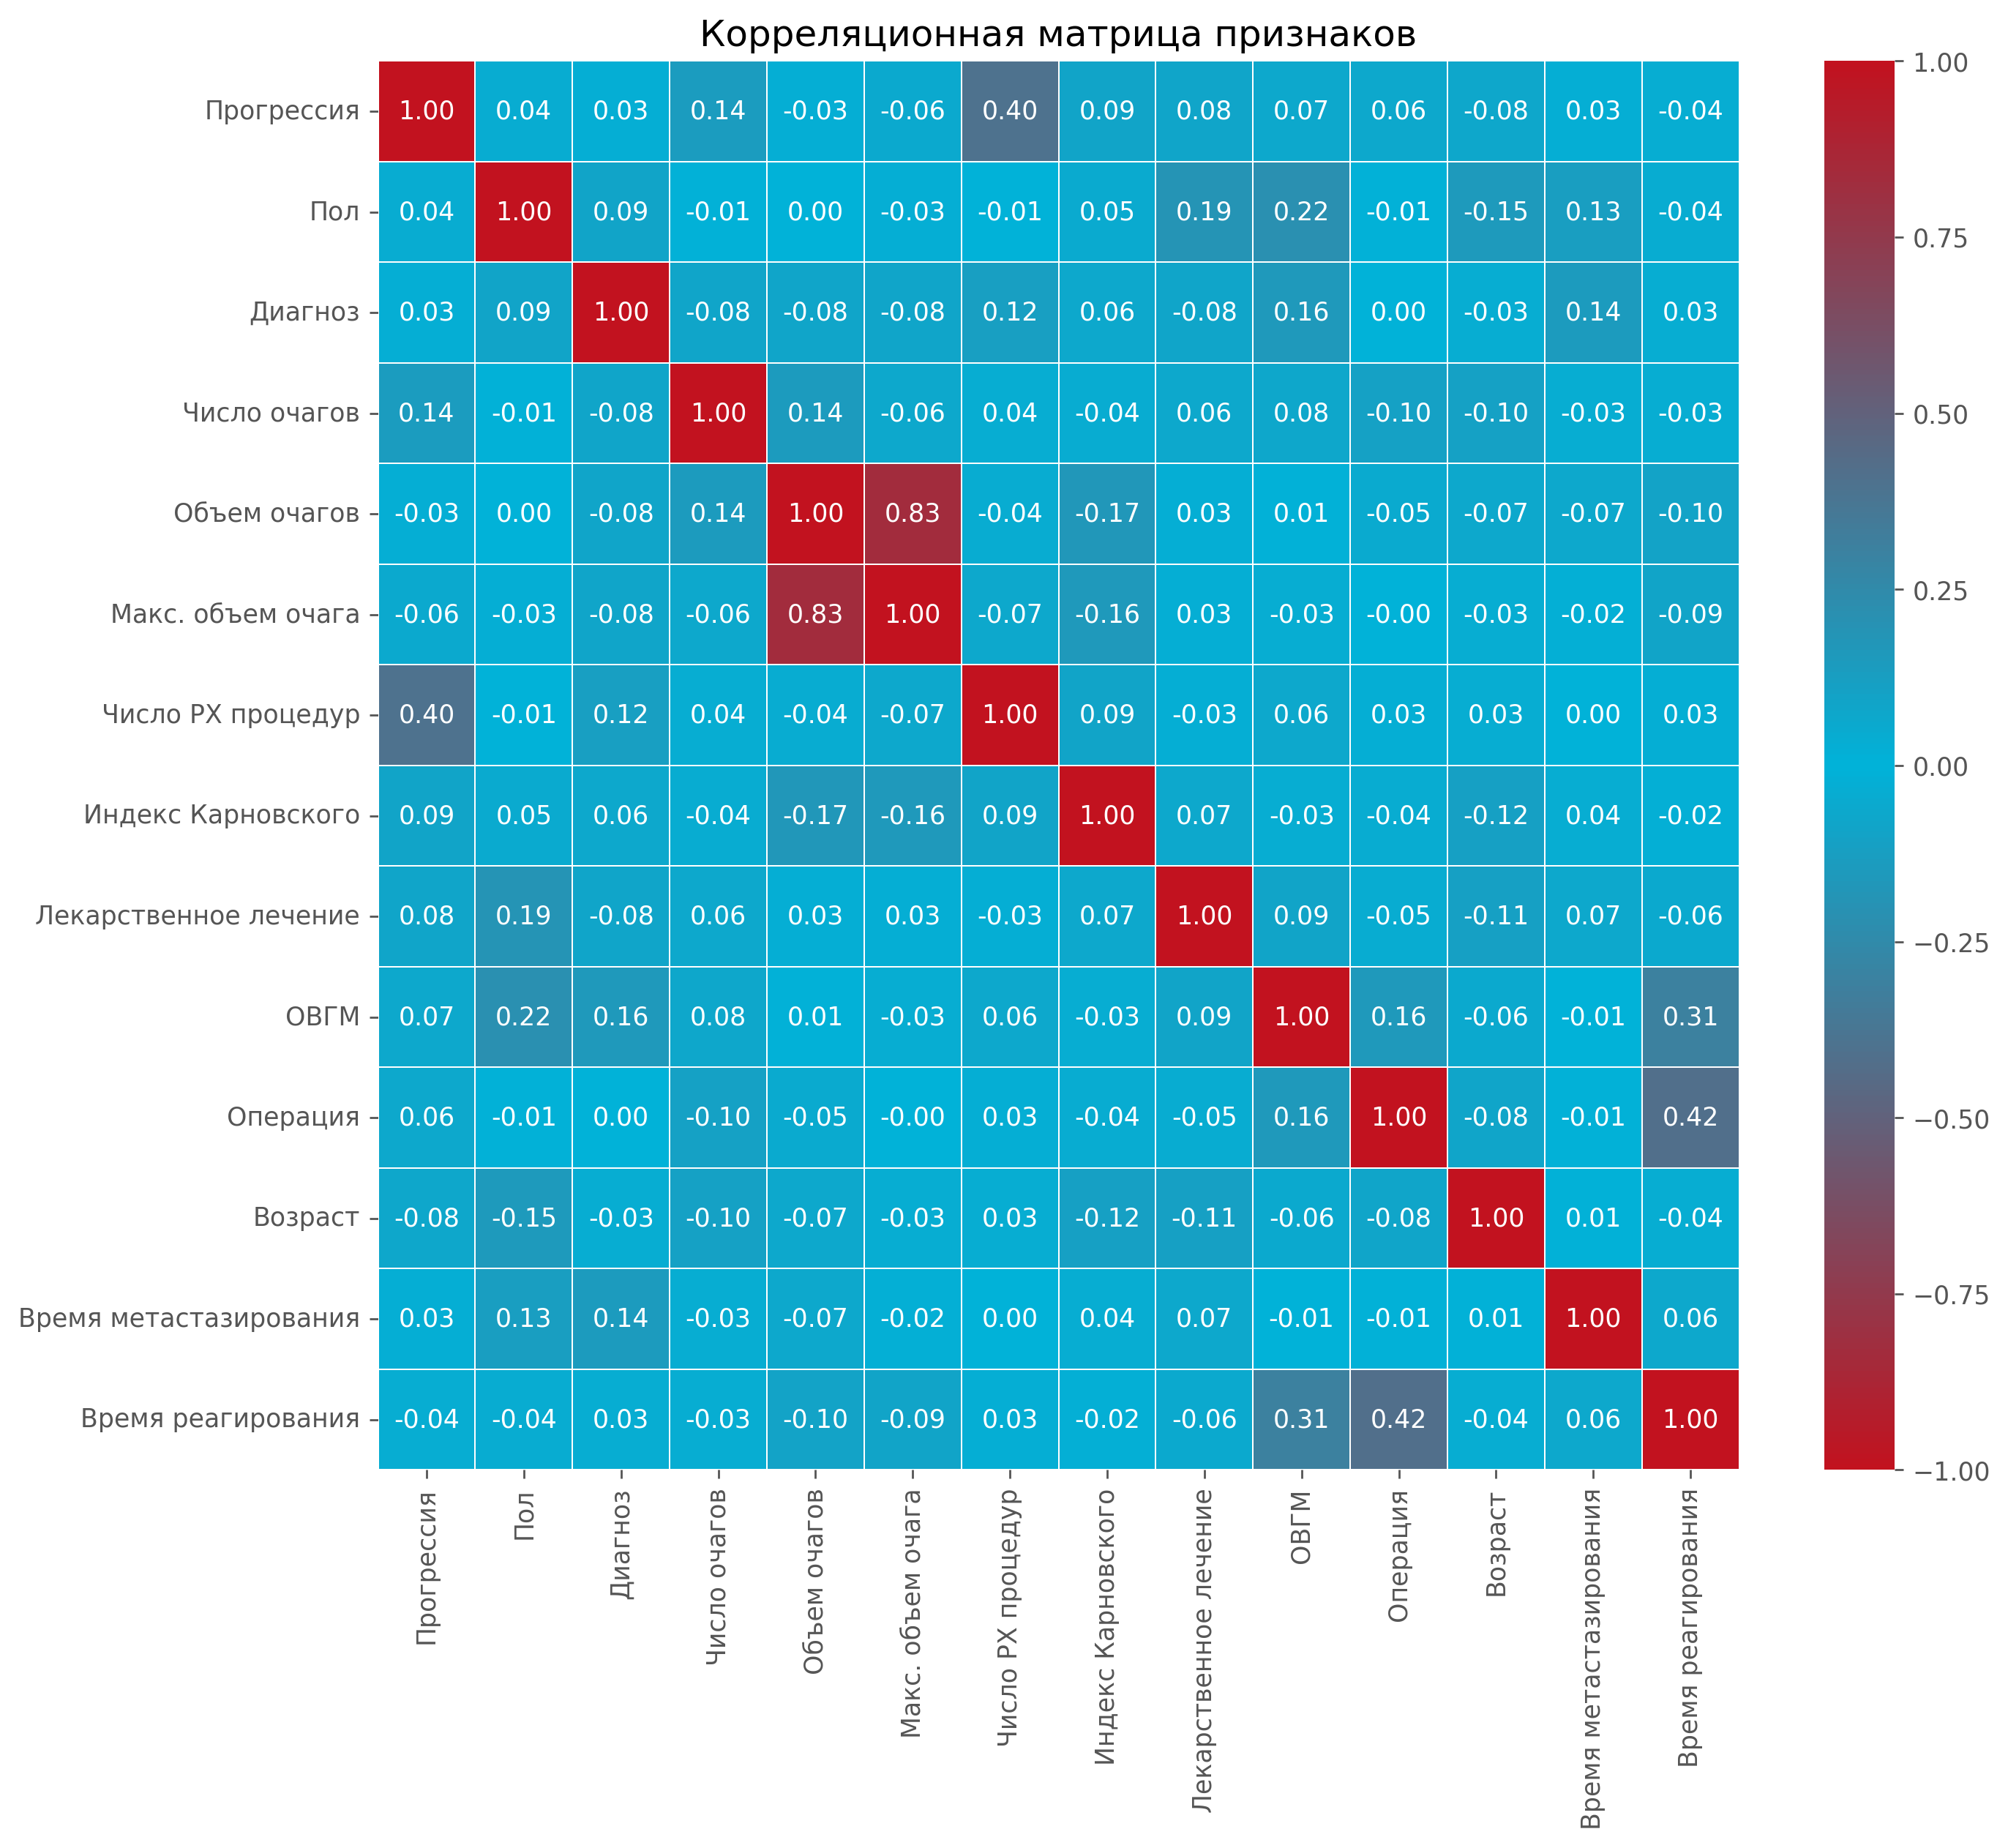

In [68]:
df_features = pd.DataFrame()
df_features['Прогрессия'] = df['Интракраниальная прогрессия'].astype(int)
df_features['Пол'] = df['Пол'].replace({'М' : '0', 'Ж' : '1'}).astype('Int8')
df_features['Диагноз'] = df['Онкологический диагноз'].astype('category').cat.codes
df_features['Число очагов'] = df['Число очагов в ГМ']
df_features['Объем очагов'] = df['Суммарный объем очагов']
df_features['Макс. объем очага'] = df['Объем максимального очага']
df_features['Число РХ процедур'] = df['Число РХ процедур на ГН']
df_features['Индекс Карновского'] = df['Индекс Карновского']
df_features['Лекарственное лечение'] = df['Лекарственное лечение'].astype('category').cat.codes
df_features['ОВГМ'] = df['ОВГМ'].astype('Int8')
df_features['Операция'] = df['Операция'].astype('Int8')
df_features['Возраст'] = df['Возраст']
df_features['Время метастазирования'] = df['Время метастазирования']
df_features['Время реагирования'] = df['Время реагирования']

colors = [(0.76, 0.07, 0.12), (0, 0.7, 0.85), (0.76, 0.07, 0.12)]
cmap = mcolors.LinearSegmentedColormap.from_list("RedBlueRed", colors)
corr_matrix = df_features.corr()
plt.figure(figsize=(12, 10), dpi=250)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Корреляционная матрица признаков')

In [69]:
df = df.drop(['Операция', 'Объем максимального очага', 'ОВГМ'], axis=1)

Операция и Объем максимального очага удалены из-за большой корреляции с другими признаками. Если оставить ОВГМ и убрать все значения в которых он является NaNом, то качество модели ухудшится

## Нормализация

In [70]:
def normalize(series):
    series = pd.to_numeric(series, errors='coerce')
    mean = series.mean()
    std = series.std()

    if pd.isna(std) or std == 0:
        return series - mean

    return (series - mean) / std


columns = [
    "Число РХ процедур на ГН",
    "Индекс Карновского",
    "Число очагов в ГМ",
    "Суммарный объем очагов",
    "Возраст",
    "Время реагирования",
    "Время метастазирования"
]
for column in columns:
  df[column] = normalize(df[column])

Вычитается среднее и делится на стандартное отклоенение

## One-hot encoding

In [71]:
def one_hot_encode(series):
    result = pd.crosstab(
        index=series.index,
        columns=series.values,
        dropna=False
    )
    return result


columns_to_hot =[
    "Онкологический диагноз",
    "Лекарственное лечение",
    "Пол"
]

for i in columns_to_hot:
  df[i] = df[i].replace(np.nan, "неизвестно")
  df2 = one_hot_encode(df[i])
  df = pd.concat([df, df2], axis=1)
  df = df.drop(i, axis=1)

df

,Дата удаления первичного очага,Активирующие мутации,Дата проведения ОВГМ,Дата операции на ГМ,Число РХ процедур на ГН,Индекс Карновского,Число очагов в ГМ,Суммарный объем очагов,Экстракраниальные метастазы,Интракраниальная прогрессия,...,Меланома,НМРЛ,РМЖ,РП,Без лечения,Таргетная терапия,Химиотерапия,неизвестно,Ж,М
0,01.01.2015,True,нет,нет,-0.600965,1.146731,2.194321,-0.922432,True,1,...,1,0,0,0,0,1,0,0,1,0
2,01.05.2015,False,нет,нет,-0.600965,-1.029020,-0.033221,-0.760292,True,0,...,0,0,1,0,0,0,1,0,1,0
4,не удален,True,нет,нет,-0.600965,0.058855,1.384306,-0.861274,True,1,...,0,1,0,0,0,1,0,0,1,0
5,не удален,False,01.09.2014,нет,-0.600965,1.146731,0.371787,-0.015017,True,1,...,0,1,0,0,0,0,1,0,1,0
7,NaN,NaN,NaN,01.03.2012,-0.600965,-1.029020,-0.843235,-0.054841,True,0,...,0,1,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
848,01.12.2017,NaN,нет,нет,0.665039,0.058855,-0.438228,-0.450235,True,1,...,0,0,0,1,0,1,0,0,1,0
849,12.02.2008,NaN,02.12.2015,нет,3.197046,0.058855,-0.640732,-0.795849,True,1,...,0,0,0,1,0,1,0,0,1,0
851,01.04.2011,NaN,NaN,NaN,-0.600965,-1.029020,0.169283,-0.413256,True,1,...,1,0,0,0,0,0,1,0,1,0
852,NaN,NaN,15.09.2010,нет,3.197046,0.058855,-0.438228,0.083120,True,1,...,0,1,0,0,0,0,1,0,0,1


# 2. Выбор модели

## Модели
В качестве кандидатов были рассмотрены логистическая регрессия, дерево решений, kNN, SVM, случайный лес, AdaBoost, CatBoost и стекинг. Основной метрикой качества выбрана F1-мера, так как задача является бинарной классификацией с дисбалансом классов.

## Обработка

In [72]:
X = pd.concat([df['М'],
               df['Ж'],
               df['КРР'],
               df['НМРЛ'],
               df['РП'],
               df['Меланома'],
               df['РМЖ'],
               df['Без лечения'],
               df['Таргетная терапия'],
               df['Химиотерапия'],
               df['неизвестно'], # речь идёт о лекарственном лечении
               df['Возраст'],
               df['Число РХ процедур на ГН'],
               df['Индекс Карновского'],
               df['Число очагов в ГМ'],
               df['Суммарный объем очагов'],
               df['Время реагирования'],
               df['Время метастазирования']], axis=1)
Y = df['Интракраниальная прогрессия']

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

results = {}

In [73]:
# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Логистическая регрессия

In [74]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test_scaled)
results['Логистическая регрессия'] = f1_score(y_test, lr_pred, average='weighted')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Дерево решений

In [75]:
dt_base = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_base.fit(X_train, y_train)
dt_pred = dt_base.predict(X_test)
results['Дерево решений'] = f1_score(y_test, dt_pred, average='weighted')

## kNN

In [76]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)
knn_pred = knn_base.predict(X_test_scaled)
results['kNN'] = f1_score(y_test, knn_pred, average='weighted')

## SVM, RBF ядро

In [77]:
svm_base = SVC(kernel='rbf', random_state=42)
svm_base.fit(X_train_scaled, y_train)
svm_pred = svm_base.predict(X_test_scaled)
results['SVM'] = f1_score(y_test, svm_pred, average='weighted')

## Случайный лес

In [78]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
results['Случайный лес'] = f1_score(y_test, rf_pred, average='weighted')

## kNN бэггинг

In [79]:
knn_bagging = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=50,
    max_samples=0.8,
    random_state=42
)
knn_bagging.fit(X_train_scaled, y_train)
knn_bagging_pred = knn_bagging.predict(X_test_scaled)
results['kNN бэггинг'] = f1_score(y_test, knn_bagging_pred, average='weighted')

## CatBoost (модель Яндекса, не из scikit-learn)

In [80]:
catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=False
)

catboost_model.fit(X_train, y_train)
catboost_pred = catboost_model.predict(X_test)
results['CatBoost'] = f1_score(y_test, catboost_pred, average='weighted')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'М'),
  Text(1, 0, 'Ж'),
  Text(2, 0, 'КРР'),
  Text(3, 0, 'НМРЛ'),
  Text(4, 0, 'РП'),
  Text(5, 0, 'Меланома'),
  Text(6, 0, 'РМЖ'),
  Text(7, 0, 'Без лечения'),
  Text(8, 0, 'Таргетная терапия'),
  Text(9, 0, 'Химиотерапия'),
  Text(10, 0, 'неизвестно'),
  Text(11, 0, 'Возраст'),
  Text(12, 0, 'Число РХ процедур на ГН'),
  Text(13, 0, 'Индекс Карновского'),
  Text(14, 0, 'Число очагов в ГМ'),
  Text(15, 0, 'Суммарный объем очагов'),
  Text(16, 0, 'Время реагирования'),
  Text(17, 0, 'Время метастазирования')])

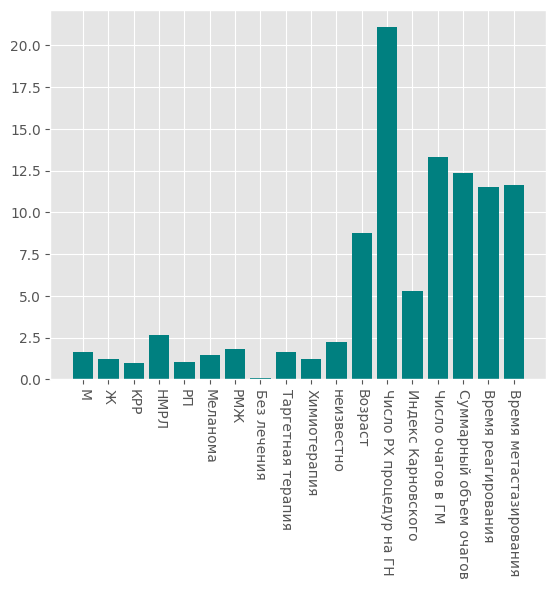

In [81]:
importance = catboost_model.get_feature_importance()
parameters = ['М', 'Ж', 'КРР', 'НМРЛ', 'РП', 'Меланома', 'РМЖ', 'Без лечения',
    'Таргетная терапия', 'Химиотерапия', 'неизвестно', 'Возраст',
    'Число РХ процедур на ГН', 'Индекс Карновского', 'Число очагов в ГМ',
    'Суммарный объем очагов', 'Время реагирования', 'Время метастазирования']
plt.bar(parameters, importance, color='teal')
plt.xticks(rotation=-90)

## AdaBoost

In [82]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42,
    learning_rate=0.8
)
adaboost_model.fit(X_train, y_train)
adaboost_pred = adaboost_model.predict(X_test)
results['AdaBoost'] = f1_score(y_test, adaboost_pred, average='weighted')

## Стекинг (Дерево решений + SVM + kNN)

In [83]:
base_models = [
    ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

meta_model = LogisticRegression(random_state=42)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

stacking_model.fit(X_train_scaled, y_train)
stacking_pred = stacking_model.predict(X_test_scaled)
results['Стекинг'] = f1_score(y_test, stacking_pred, average='weighted')

## Результаты

In [84]:
results

{'Логистическая регрессия': 0.6928181658158774,
 'Дерево решений': 0.6296675191815856,
 'kNN': 0.6643702664796635,
 'SVM': 0.6481841432225064,
 'Случайный лес': 0.6318435188000405,
 'kNN бэггинг': 0.6757525083612039,
 'CatBoost': 0.7254480073702042,
 'AdaBoost': 0.709883823270551,
 'Стекинг': 0.6344753890335939}

# 3. Подбор гиперпараметров

In [85]:
# model = CatBoostClassifier(
#     loss_function='Logloss',
#     eval_metric='F1',
#     random_seed=42,
#     verbose=False,
#     early_stopping_rounds=50
# )
# cv = ShuffleSplit(n_splits=50, random_state=42, test_size=0.2)

## Случайный выбор (Кросс-валидация - ShuffleSplit)

In [86]:
# param_dist = {
#     'iterations': randint(300, 1500),
#     'learning_rate': uniform(0.01, 0.2),
#     'depth': randint(4, 10),
#     'l2_leaf_reg': uniform(1, 10),
#     'border_count': randint(32, 255),
#     'bagging_temperature': uniform(0, 1),
#     'random_strength': uniform(0, 1)
# }

# random_search = RandomizedSearchCV(
#     estimator=model,
#     param_distributions=param_dist,
#     n_iter=30,
#     cv=cv,
#     scoring=make_scorer(f1_score, average='weighted'),
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# random_search.fit(X_train, y_train)
# random_search.best_score_

0.7 - Результат хуже чем без подбора гиперпараметров

# Тестирование

In [87]:
df = pd.read_csv('test.csv')

## Фильтрация

### Булевые признаки

In [88]:
def to_bool(series):
  result = series.copy()
  result = result.replace({
      'есть': True,
      'нет': False
  })
  return result

df["Экстракраниальные метастазы"] = to_bool(df["Экстракраниальные метастазы"])
df["Активирующие мутации"] = to_bool(df["Активирующие мутации"])

print(df["Экстракраниальные метастазы"].unique())
print(df["Активирующие мутации"].unique())

[nan True False]
[nan False True]


### Признаки с плавающей точкой

In [89]:
def str_to_float(series):
  result = series.copy()
  result = result.str.replace(',', '.')
  result = result.apply(float)
  return result


df['Суммарный объем очагов'] = str_to_float(df['Суммарный объем очагов'])
df['Объем максимального очага'] = str_to_float(df['Объем максимального очага'])

### Пол

In [90]:
def normalize_sex(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x == 'м':
        return 'М'
    if x == 'ж':
        return 'Ж'
    return np.nan

df['Пол'] = df['Пол'].apply(normalize_sex)

### Замена "нет" на NaN

In [91]:
df['Дата развития МГМ'] = df['Дата развития МГМ'].replace("нет", np.nan)
df['Дата постановки онкологического диагноза / начала первичного лечения'] = df['Дата постановки онкологического диагноза / начала первичного лечения'].replace("нет", np.nan)

### Избавление от NaN

In [92]:
df = df.dropna(subset=["Дата развития МГМ", "Дата постановки онкологического диагноза / начала первичного лечения"]).copy()

## Добавление признаков

### Возраст

In [93]:
def calculate_age(birth, first_rx):
    birth = pd.to_datetime(birth, errors='coerce')
    first_rx = pd.to_datetime(first_rx, errors='coerce')
    if pd.isna(birth) or pd.isna(first_rx):
        return np.nan
    age = first_rx.year - birth.year
    if (first_rx.month, first_rx.day) < (birth.month, birth.day):
        age -= 1
    return age


df["Возраст"] = df.apply(lambda row: calculate_age(row["Дата рождения"], row["Дата 1-ой РХ"]), axis=1)
df = df.drop('Дата рождения', axis=1)

/tmp/ipykernel_7499/3858549362.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  birth = pd.to_datetime(birth, errors='coerce')
/tmp/ipykernel_7499/3858549362.py:3: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  first_rx = pd.to_datetime(first_rx, errors='coerce')


### Время реагирования

In [94]:
def time_to_react(mgm, first):
    mgm = pd.to_datetime(mgm, errors='coerce')
    first = pd.to_datetime(first, errors='coerce')
    if pd.isna(mgm) or pd.isna(first):
        return np.nan
    return (first - mgm).days


df["Время реагирования"] = df.apply(lambda row: time_to_react(row["Дата развития МГМ"], row["Дата 1-ой РХ"]), axis=1)
df["Время реагирования"] = pd.to_numeric(df["Время реагирования"], errors='coerce')
df = df[df["Время реагирования"] >= 0]
df = df.drop('Дата 1-ой РХ', axis=1)

/tmp/ipykernel_7499/2789776970.py:3: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  first = pd.to_datetime(first, errors='coerce')
/tmp/ipykernel_7499/2789776970.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  mgm = pd.to_datetime(mgm, errors='coerce')


### Время метастазирования

In [95]:
def time_to_mgm(mgm1, first_seen):
    mgm1 = pd.to_datetime(mgm1, errors='coerce')
    first_seen = pd.to_datetime(first_seen, errors='coerce')
    if pd.isna(mgm1) or pd.isna(first_seen):
        return np.nan
    return (mgm1 - first_seen).days


df["Время метастазирования"] = df.apply(lambda row: time_to_mgm(row["Дата развития МГМ"], row["Дата постановки онкологического диагноза / начала первичного лечения"]), axis=1)
df["Время метастазирования"] = pd.to_numeric(df["Время метастазирования"], errors='coerce')
df = df.drop(['Дата развития МГМ', 'Дата постановки онкологического диагноза / начала первичного лечения'], axis=1)

/tmp/ipykernel_7499/1289759378.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  mgm1 = pd.to_datetime(mgm1, errors='coerce')
/tmp/ipykernel_7499/1289759378.py:3: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  first_seen = pd.to_datetime(first_seen, errors='coerce')


### Операции

In [96]:
def map_binary(x):
    if pd.isna(x):
        return np.nan
    elif str(x).strip().lower() == 'нет':
        return 0
    else:
        return 1


df['ОВГМ'] = df['Дата проведения ОВГМ'].apply(map_binary)
df['Операция'] = df['Дата операции на ГМ'].apply(map_binary)

## Поиск лишних признаков

In [97]:
df = df.drop(['Операция', 'Объем максимального очага', 'ОВГМ'], axis=1)

## Нормализация

In [98]:
def normalize(series):
    series = pd.to_numeric(series, errors='coerce')
    mean = series.mean()
    std = series.std()

    if pd.isna(std) or std == 0:
        return series - mean

    return (series - mean) / std


columns = [
    "Число РХ процедур на ГН",
    "Индекс Карновского",
    "Число очагов в ГМ",
    "Суммарный объем очагов",
    "Возраст",
    "Время реагирования",
    "Время метастазирования"
]
for column in columns:
  df[column] = normalize(df[column])

Вычитается среднее и делится на стандартное отклоенение

## One-hot encoding

In [99]:
def one_hot_encode(series):
    result = pd.crosstab(
        index=series.index,
        columns=series.values,
        dropna=False
    )
    return result


columns_to_hot =[
    "Онкологический диагноз",
    "Лекарственное лечение",
    "Пол"
]

for i in columns_to_hot:
  df[i] = df[i].replace(np.nan, "неизвестно")
  df2 = one_hot_encode(df[i])
  df = pd.concat([df, df2], axis=1)
  df = df.drop(i, axis=1)

df

,ID,Дата удаления первичного очага,Активирующие мутации,Дата проведения ОВГМ,Дата операции на ГМ,Число РХ процедур на ГН,Индекс Карновского,Число очагов в ГМ,Суммарный объем очагов,Экстракраниальные метастазы,...,КРР,Меланома,НМРЛ,РМЖ,РП,Без лечения,Таргетная терапия,Химиотерапия,Ж,М
0,1,не удален,NaN,нет,нет,0.936767,-1.194281,0.373560,0.510777,NaN,...,0,0,1,0,0,0,0,1,1,0
1,2,01.01.2009,NaN,нет,нет,0.936767,0.091868,-0.788626,-0.605747,NaN,...,0,1,0,0,0,1,0,0,0,1
2,3,01.02.2010,NaN,нет,нет,-0.576472,0.091868,-0.982324,-0.637785,NaN,...,0,1,0,0,0,0,0,1,1,0
3,4,NaN,False,нет,нет,-0.576472,-2.480430,0.179862,0.054236,True,...,0,0,0,1,0,0,0,1,1,0
4,5,не удален,NaN,нет,нет,-0.576472,-1.194281,-0.788626,-0.445557,True,...,0,0,0,0,1,0,0,1,1,0
5,6,01.01.2011,NaN,нет,30.06.2014,-0.576472,0.091868,-0.982324,0.129525,True,...,1,0,0,0,0,0,0,1,1,0
6,7,не удален,True,нет,нет,0.936767,1.378017,1.729444,0.664559,True,...,0,0,1,0,0,0,1,0,1,0
7,8,не удален,True,нет,нет,-0.576472,0.091868,-0.788626,-1.142383,True,...,0,0,0,1,0,0,1,0,1,0
8,9,01.08.2013,False,нет,нет,-0.576472,1.378017,-0.982324,-0.149205,True,...,0,0,0,1,0,0,0,1,1,0
9,10,не удален,False,нет,нет,2.450007,0.091868,1.342048,1.689775,True,...,0,0,0,1,0,0,0,1,1,0


## Предсказание

In [100]:
df['неизвестно'] = pd.Series(0, index=range(df.shape[0]))

In [101]:
X = pd.concat([df['М'],
               df['Ж'],
               df['КРР'],
               df['НМРЛ'],
               df['РП'],
               df['Меланома'],
               df['РМЖ'],
               df['Без лечения'],
               df['Таргетная терапия'],
               df['Химиотерапия'],
               df['неизвестно'], # речь идёт о лекарственном лечении
               df['Возраст'],
               df['Число РХ процедур на ГН'],
               df['Индекс Карновского'],
               df['Число очагов в ГМ'],
               df['Суммарный объем очагов'],
               df['Время реагирования'],
               df['Время метастазирования']], axis=1)
predictions = catboost_model.predict(X)

In [102]:
ids = np.arange(1, df.shape[0]+1)
submission = pd.DataFrame({'ID':ids, 'prediction':predictions})
submission.to_csv('submission.csv', index=False)